# 230352K Kumara K.B.R  
## Assesment 01 - Intensity Transformations and Neighborhood Filtering
#### 1 Intensity transform 

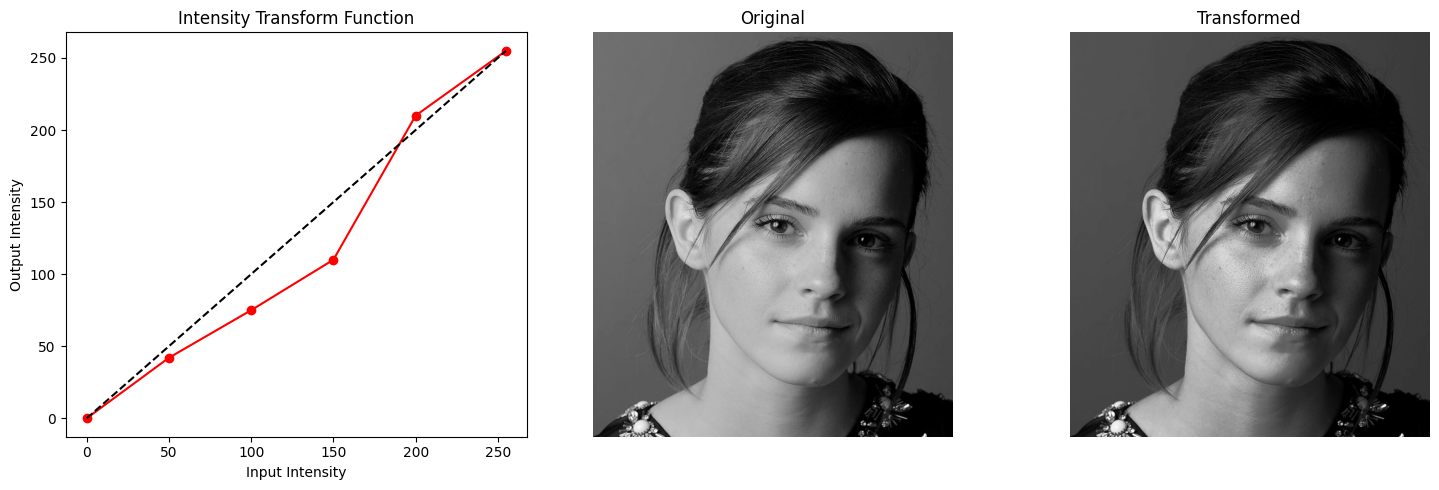

In [73]:
# importing required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

#function to display images alongside with the intensity transform function
def show_image_3(title, image_before, image_after=None, breakpoints=None):

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    if breakpoints is not None:
        axes[0].plot(breakpoints[:, 0], breakpoints[:, 1], 'ro-')
        axes[0].plot(np.arange(256), np.arange(256), 'k--')
        axes[0].set_title("Intensity Transform Function")
        axes[0].set_xlabel("Input Intensity")
        axes[0].set_ylabel("Output Intensity")
    axes[1].imshow(image_before, cmap='gray')
    axes[1].set_title(title)
    axes[1].axis('off')
    if image_after is not None:
        axes[2].imshow(image_after, cmap='gray')
        axes[2].set_title("Transformed")
        axes[2].axis('off')
    plt.tight_layout()
    plt.show()

# Intensity transform function
def intensity_transform(im, breakpoints):
    # Create a lookup table for intensity transformation
    xp = breakpoints[:, 0]
    fp = breakpoints[:, 1]  
    lut = np.interp(np.arange(256), xp, fp).astype('uint8')
    return lut[im]

im1 = cv2.imread('images/q1.jpeg', cv2.IMREAD_GRAYSCALE) #read image in grayscale
breakpoints = np.array([[0, 0], [50, 42], [100, 75], [150, 110], [200, 210], [ 255, 255]]) #defining breakpoints for intensity transformation
transformed = intensity_transform(im1, breakpoints) #transformed image

show_image_3("Original", im1, transformed,breakpoints)


- We can see that by adjusting the breakpoints of the breakpoints array we can change the intensity transform accordingly.
- To enhance the image we can reduce the overall brighness because the image is towards more brighter area
- Adjusting the intensity transform to reduce the brighness of white pixels we can get a visually pleasing output of the image

### 2 Medical image analysis
#### we can use intensity transform to highlight gray matter and whitematter areas in MRI scan of a brain

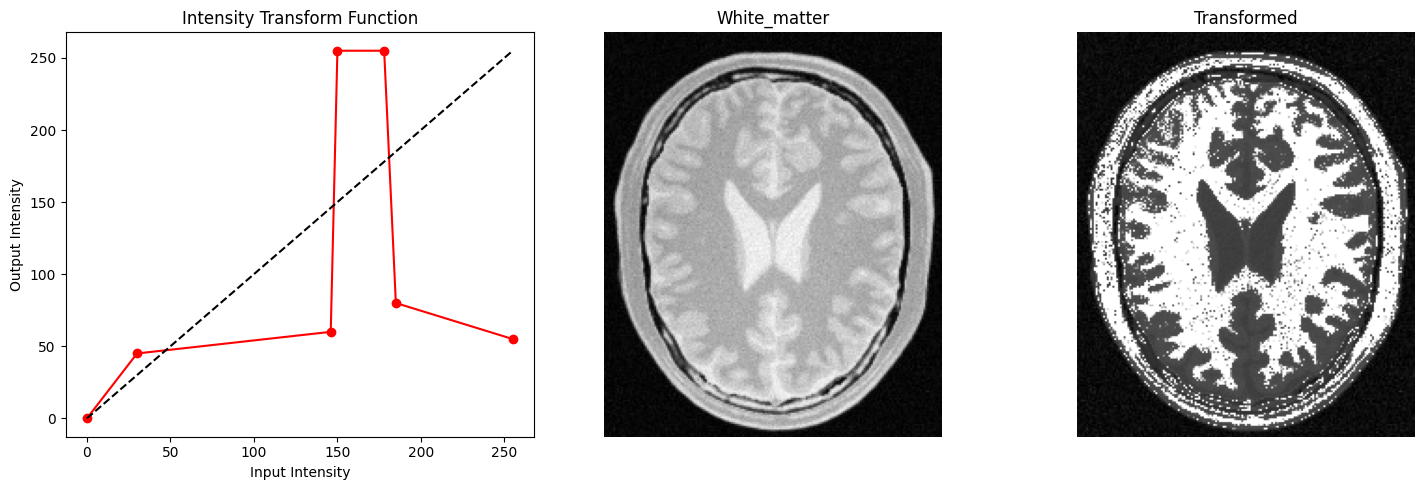

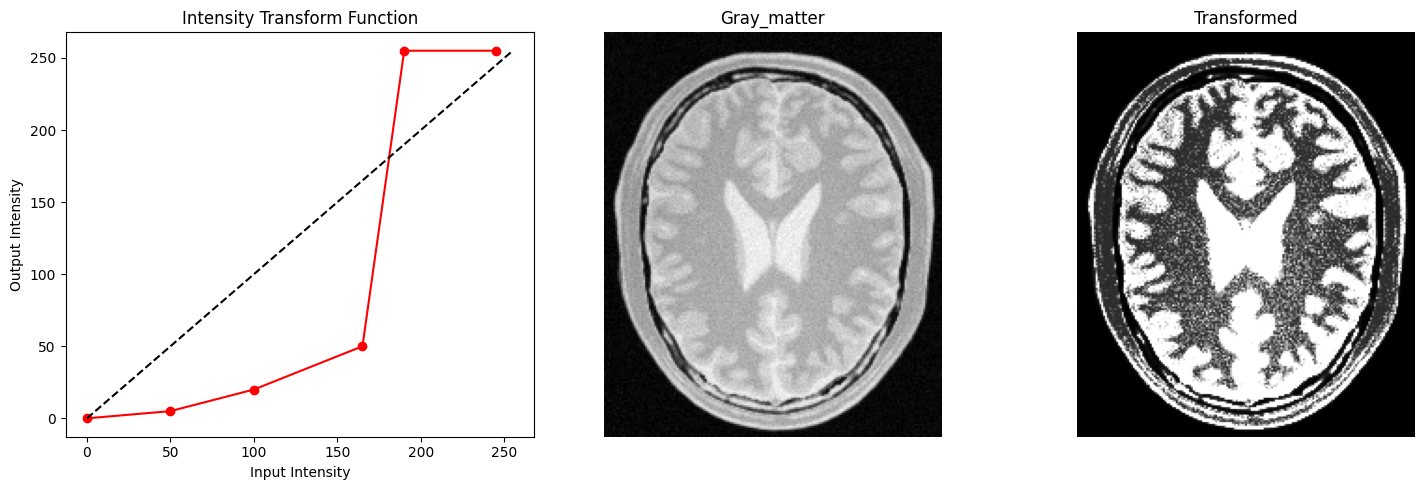

In [102]:
im2 = cv2.imread('images/q2.jpeg', cv2.IMREAD_GRAYSCALE)

white = np.array([[0, 0], [30,45], [146, 60], [150, 255],  [178, 255], [185, 80], [ 255, 55]]) # breakpoints for white accentuation
white_accentuated = intensity_transform(im2, white)

black = np.array([[0, 0], [50, 5], [100, 20], [165, 50],  [190, 255], [ 245, 255]]) # breakpoints for black accentuation
black_accentuated = intensity_transform(im2, black)
show_image_3("White_matter", im2, white_accentuated, white)
show_image_3("Gray_matter", im2, black_accentuated, black)

- By using different intensity transformations we can highlight certain pixel ranges in an MRI scan of a brain
- In white matter highlighting we can see that the white matter pixel values are in range 150-180 range, therefore we can use an intensity transfrom which boosts the pixels in that range and supress other pixels
- In Gray matter highlighting we can see that the gray matter pixels are in range 190-250 ,We can use an intensity transform which boosts pixel values in those area and supress other pixels 
- We can use this method in segmenting different pixel range objects in a given image

### 3 Gamma correction
#### We apply a gamma correction algorithm to enhance image color and quality

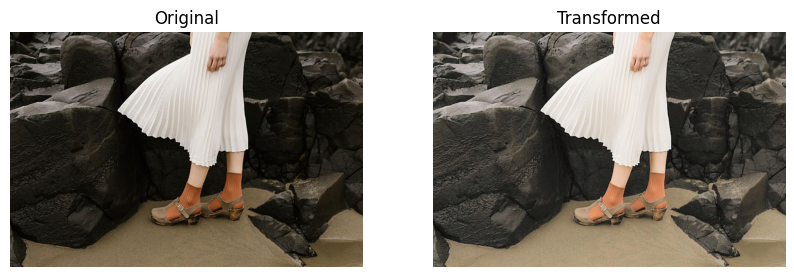

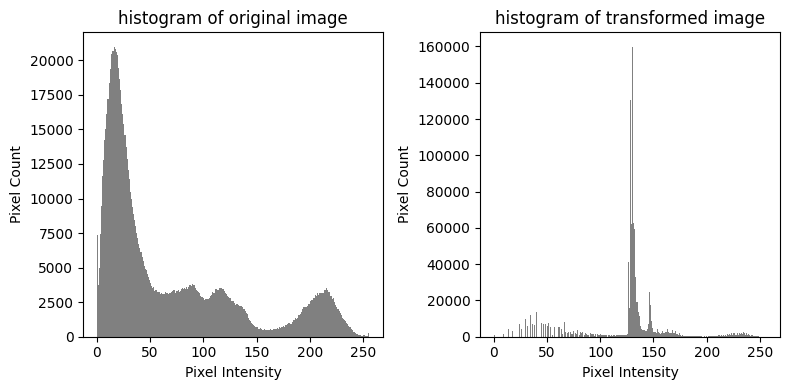

In [ ]:
im3 = cv2.imread('images/q3.jpeg')
lab_image = cv2.cvtColor(im3, cv2.COLOR_BGR2LAB) # convert the image from BGR to LAB color space
l = lab_image[:, :, 0] #extract the L channel (lightness) from the LAB image

gamma = 0.6 # Experiment and choose a suitable gamma value for the transformation
lut = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8") #gamma correction lookup table
l_transformed = cv2.LUT(l, lut) 

#function to display images before and after a transformation
def show_image_2(title, image_before, image_after=None):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image_before, cmap='gray')
    axes[0].set_title(title)
    axes[0].axis('off')
    if image_after is not None:
        axes[1].imshow(image_after, cmap='gray')
        axes[1].set_title("Transformed")
        axes[1].axis('off')
    plt.show()

img_rgb_original = cv2.cvtColor(im3, cv2.COLOR_BGR2RGB)
im3_transformed = cv2.merge((l_transformed, lab_image[:, :, 1], lab_image[:, :, 2]))
img_rgb_corrected = cv2.cvtColor(im3_transformed, cv2.COLOR_LAB2RGB) # gamma correctted image in RGB color space
show_image_2("Original", img_rgb_original, img_rgb_corrected)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].hist(im3.ravel(), bins=256, range=[0, 256], color='gray') #getting and plotting histogram of original image
axes[0].set(title="histogram of original image", xlabel="Pixel Intensity", ylabel="Pixel Count")
axes[1].hist(im3_transformed.ravel(), bins=256, range=[0, 256], color='gray') # getting and plotting histogram of transformed image
axes[1].set(title="histogram of transformed image", xlabel="Pixel Intensity", ylabel="Pixel Count")
plt.tight_layout()
plt.show()


- for this transform we decouple the image into the L*a*b space and apply the gamma correction to the L plane
- gamma correction is a non-linear intensity transfromation by applying $\gamma < 1.0$ (e.g., $0.5$) non-linearly brightens dark shadow details, whereas $\gamma > 1.0$ darkens bright regions to compress highlights.
- By applying the gamma correction only to the L plane we can isolate the original hue and saturation planes as it is and only change the brightness of the image
- Here because the origianl image is more darker and hides details we use an $\gamma < 1.0$ for the gamma correction
- $L^*$ histogram shifts rightward (for $\gamma < 1.0$), stretching previously compressed dark pixel values across a wider dynamic range.

### 4 Increasing vibrance of an image
#### We breakdown a given image into HSV space and apply a non-linear intensity transform to the saturation plane to enhance the vibrance of the image

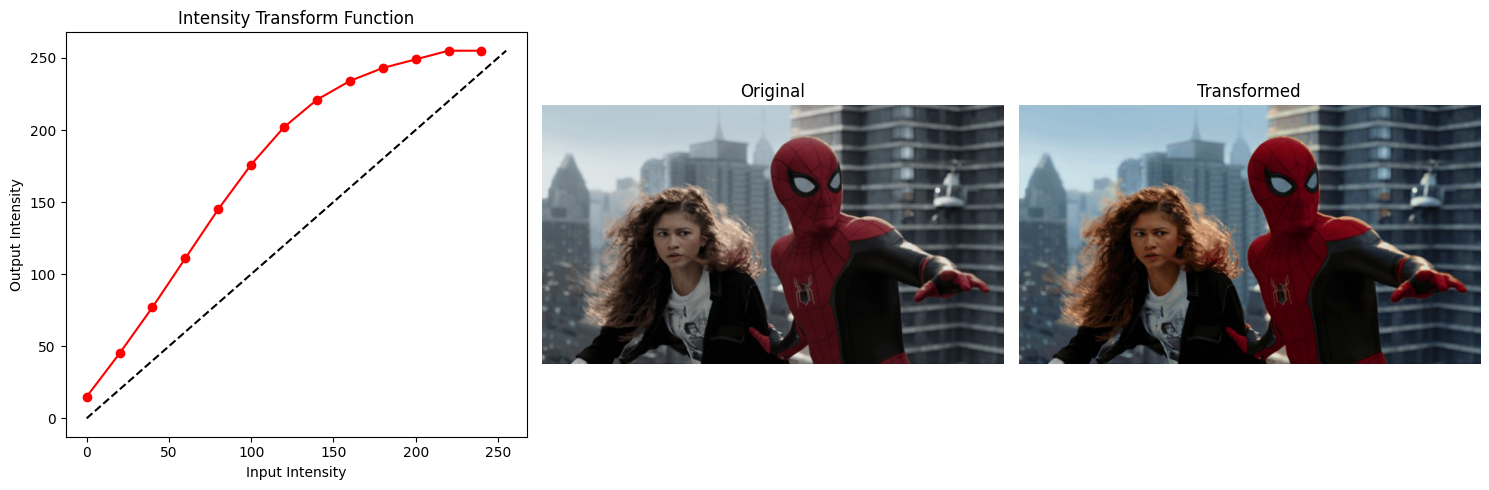

In [105]:
im4 = cv2.imread('images/q4.jpeg')
hsv_image = cv2.cvtColor(im4, cv2.COLOR_BGR2HSV)  # convert the image from BGR to HSV color space
h, s, v = cv2.split(hsv_image) # split the HSV image into its three channels

a = 0.65   # Experiment and choose a suitable value for the transformation 
sigma = 70 
x = np.arange(256)
boost = a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)) #calculating the boost values for each intensity level using a Gaussian function
lut_hsv = np.minimum(x + boost, 255).astype(np.uint8) #the lookup table for the transformation, ensuring that the values do not exceed 255

im4_transformed = cv2.merge((h, cv2.LUT(s, lut_hsv), v)) #apply the transformation to the S channel using the lookup table and merge the channels back together to get the transformed HSV image
im4_rgb_original = cv2.cvtColor(im4, cv2.COLOR_BGR2RGB) #convert the original image from BGR to RGB color space for display
im4_rgb_transformed = cv2.cvtColor(im4_transformed, cv2.COLOR_HSV2RGB) #convert the transformed image from HSV to RGB color space for display

curve_points = np.column_stack((x[::20], lut_hsv[::20])) #breakpoints for the intensity transformation curve, taking every 20th point from the lookup table for display purposes

show_image_3("Original", im4_rgb_original, im4_rgb_transformed, curve_points)


- We the image to the HSV color space and isolates saturation ($S$) from lightness ($V$) and hue ($H$). and apply the transfrom only for the isolated Saturation space
- This non linear transformation selectively targets the mid range saturation levels by using a gaussian profile centered at 128
- The term $e^{-\frac{(x-128)^2}{2\sigma^2}}$ acts as a smooth bell-curve gain filter. It applies maximum boost to muted mid-tones while naturally tapering off toward the extremes ($x \to 0$ and $x \to 255$), preserving neutral grays and preventing extreme saturation blooming.
- The factor $a \in [0, 1]$ scales the peak height of the Gaussian boost. Adjusting $a$ enables fine-grained control over vibrancy, allowing muted colors to pop while avoiding unnatural, oversaturated artifacts.
- By applying this transformation to the S plane of an image we can get an vibrance enhanced image 

### 5 Histogram equalization
#### Implement a custom fuction to perform the histogram equalization of a given image

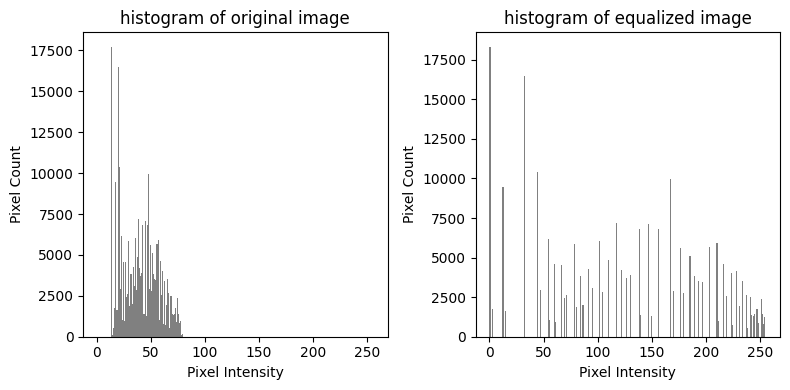

In [106]:
im5 = cv2.imread('images/q5.tif', cv2.IMREAD_GRAYSCALE)

#custom histogram_equalization function
def histogram_equalization(im):

    hist, bins = np.histogram(im.flatten(), 256, [0, 256]) # calculate the histogram of the image
    cdf = hist.cumsum() # get the cumulative distribution function (CDF) of the histogram
    cdf_normalized = cdf * hist.max() / cdf.max() # normalize the CDF to the range of the histogram
    cdf_m = np.ma.masked_equal(cdf, 0) # mask the CDF to ignore zero values
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min()) # scale the CDF to the range [0, 255]
    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8') #get the final CDF values, filling masked values with 0 and converting to uint8
    return cdf_final[im] 

equalized_image = histogram_equalization(im5) #apply histogram equalization to the image

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].hist(im5.ravel(), bins=256, range=[0, 256], color='gray') #plotting histogram of original image
axes[0].set(title="histogram of original image", xlabel="Pixel Intensity", ylabel="Pixel Count")
axes[1].hist(equalized_image.ravel(), bins=256, range=[0, 256], color='gray') #plotting histogram of equalized image
axes[1].set(title="histogram of equalized image", xlabel="Pixel Intensity", ylabel="Pixel Count")
plt.tight_layout()
plt.show()

- We can see that after the histogram equalization process the histogram of the input image has now equally distributed over the pixel range giving a balanced and equalized histogram of the image
- Histogram equalization redistributes clustered pixel intensities across the full $[0, 255]$ dynamic range, significantly improving global contrast and revealing hidden structural details in low-contrast regions.
- The normalized Cumulative Distribution Function (CDF) acts as a non-linear transformation function $T(r)$, mapping original gray levels to new intensity values proportional to their cumulative probabilities.
- Using the final transformed CDF array as an index map (cdf_final[im]) acts as an efficient Look-Up Table (LUT), replacing slow nested pixel loops with vectorized $O(1)$ replacement.

### 6 Foreground masking and Histogram equalization
#### Here we apply the histogram equalization only to the foreground of an input image

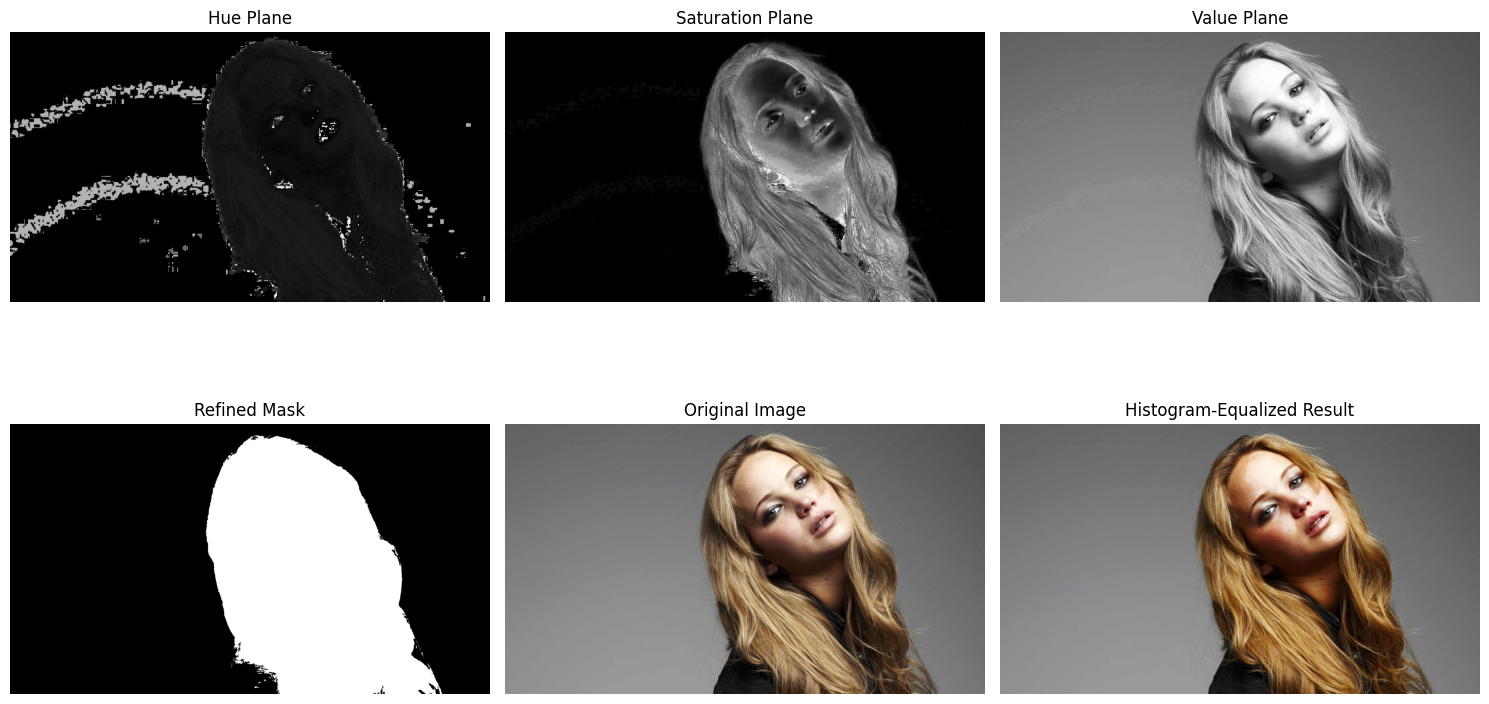

In [107]:
im6 = cv2.imread('images/q6.jpeg')
im6_hsv = cv2.cvtColor(im6, cv2.COLOR_BGR2HSV) #convert the image from BGR to HSV color space
h, s, v = cv2.split(im6_hsv)  #split the HSV image into its three channels

img_rgb = cv2.cvtColor(im6, cv2.COLOR_BGR2RGB) #convert the original image from BGR to RGB color space for display
threshold_val, mask = cv2.threshold(s, 15, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) #Use otsu's method to determine the optimal threshold value for separating the foreground from the background based on the saturation channel. The resulting binary mask is used to isolate the foreground of the image.

foreground = cv2.bitwise_and(img_rgb, img_rgb, mask=mask) #calculate the foreground of the image by applying the binary mask to the original RGB image, effectively isolating the areas of interest based on saturation.
valid_foreground_pixels = foreground[mask == 255] #get the pixel values of the foreground where the mask is 255 (i.e., the foreground pixels)

hist, bins = np.histogram(valid_foreground_pixels.ravel(), bins=256, range=[1, 256]) #calculate the histogram of the valid foreground pixels, ignoring the background pixels (which have a value of 0) by setting the range to [1, 256]. This histogram will be used for histogram equalization of the saturation channel.
cdf = np.cumsum(hist)
cdf_masked = np.ma.masked_equal(cdf, 0)
cdf_normalized = ((cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min()))
lut = np.ma.filled(cdf_normalized, 0).astype(np.uint8)

s_equalized = cv2.LUT(s, lut) #apply the histogram equalization to the saturation channel using the lookup table generated from the CDF of the valid foreground pixels. This enhances the contrast of the saturation channel while preserving the color information in the image.
img_hsv_eq = cv2.merge((h, s_equalized, v)) #merge the equalized saturation channel with the original hue and value channels
img_rgb_eq = cv2.cvtColor(img_hsv_eq, cv2.COLOR_HSV2RGB) #convert the equalized HSV image back to RGB color space

foreground_eq = cv2.bitwise_and(img_rgb_eq, img_rgb_eq, mask=mask) #apply the equalized image to the foreground region

mask_inv = cv2.bitwise_not(mask)
background = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_inv) #get the background of the image by applying the inverse of the binary mask to the original RGB image, effectively isolating the areas that were not part of the foreground.

final_image = cv2.add(foreground_eq, background) #combine the equalized foreground and the original background to get the final image with enhanced saturation in the foreground while preserving the original background.

# List of image data, titles, and colormaps
images = [h, s, v, refined_mask, img_rgb, final_image]
titles = [
    "Hue Plane",
    "Saturation Plane",
    "Value Plane",
    "Refined Mask",
    "Original Image",
    "Histogram-Equalized Result",
]
cmaps = ["gray", "gray", "gray", "gray", None, None]

# Plot all 6 outputs in a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, img, title, cmap in zip(axes.flat, images, titles, cmaps):
    ax.imshow(img, cmap=cmap) if cmap else ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


-  The Saturation ($S$) channel provides high contrast between the vibrant foreground and duller background, allowing Otsu's automated method (THRESH_OTSU) to isolate an accurate binary mask without manual parameter tuning.
- Calculating the histogram strictly on valid foreground pixels (excluding zero-intensity background pixels) prevents a massive zero-bin peak from distorting the Cumulative Distribution Function (CDF).
-  Normalizing the masked CDF to $[0, 255]$ builds a Look-Up Table (LUT) that redistributes compressed saturation levels across the full dynamic range using efficient $O(1)$ mapping via cv2.LUT.
- Inverting the binary mask (cv2.bitwise_not) isolates the untouched background, allowing cv2.add to merge the equalized foreground with the original background without introducing unwanted noise or color distortion to the surrounding scene.
- After applying the histogram eqalization only to the foreground we can see that the image quality has enhanced while keeping the background same but made the subject of the image more vibrant

### 7 Sobel filtering 
#### We can detect edges using the sobel filter

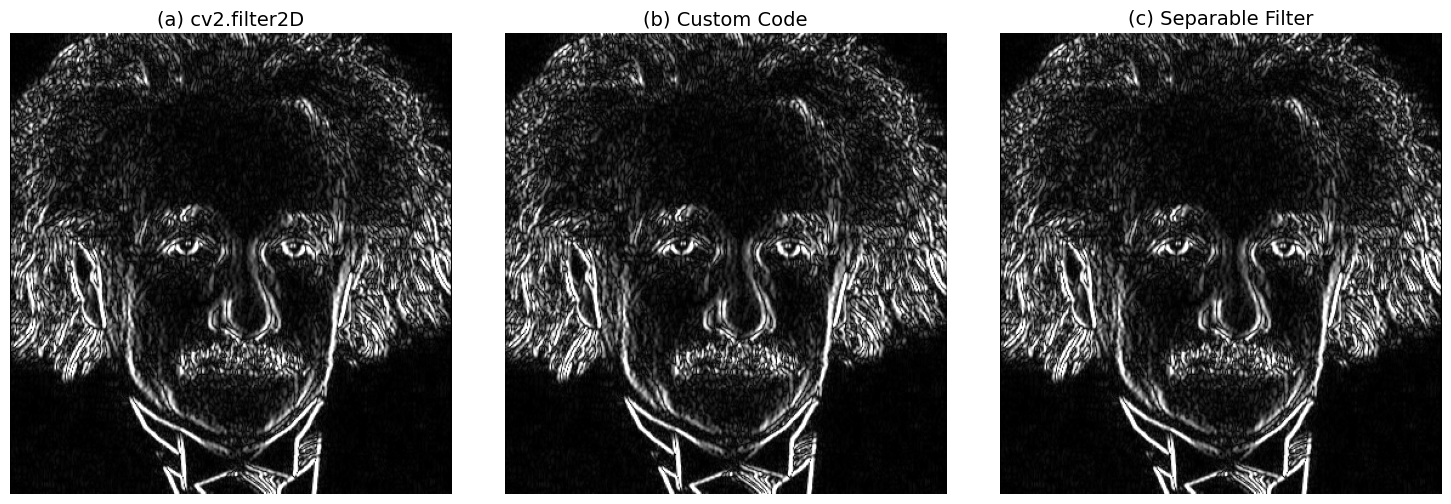

In [109]:
im7 = cv2.imread('images/q7.jpeg', cv2.IMREAD_GRAYSCALE)
sobel_kernel = np.array([[1, 0, -1],[2, 0, -2],[1, 0, -1]], dtype=np.float32) #defining the Sobel kernel for edge detection in the horizontal direction

sobel_a = cv2.filter2D(im7, cv2.CV_64F, sobel_kernel) #sobel edge detection using OpenCV's filter2D function

#impelemnt a custom Sobel filter function that takes an image and a kernel as input and returns the filtered image.
def custom_sobel(image, kernel): 
    h, w = image.shape
    padded = np.pad(image, pad_width=1, mode='edge')
    output = np.zeros((h, w), dtype=np.float64)

    for i in range(3):
        for j in range(3):
            output += padded[i:i+h, j:j+w] * kernel[i, j]
    return output

sobel_b = custom_sobel(im7, sobel_kernel) #calculate the Sobel edge detection using the custom function

#breakdown the Sobel kernel into two 1D kernels for separable filtering
col_kernel = np.array([[1], [2], [1]], dtype=np.float32)
row_kernel = np.array([[1, 0, -1]], dtype=np.float32)

# apply two 1D convolutions to achieve the same effect as the 2D Sobel filter
sobel_c_step1 = cv2.filter2D(im7, cv2.CV_64F, row_kernel)
sobel_c = cv2.filter2D(sobel_c_step1, cv2.CV_64F, col_kernel)

results = [sobel_a, sobel_b, sobel_c]
display_images = [cv2.convertScaleAbs(res) for res in results]
titles = ["(a) cv2.filter2D", "(b) Custom Code", "(c) Separable Filter"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img, title in zip(axes, display_images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

-  Convolving with the Sobel kernel estimates horizontal intensity gradients ($\partial I / \partial x$), highlighting vertical edges while suppressing smooth, uniform regions.
- The custom implementation avoids slow spatial $O(H \cdot W)$ pixel loops by slicing and weighting padded 2D sub-grids (padded[i:i+h, j:j+w]), accumulating all neighbor multiplications simultaneously via vectorized NumPy operations.
-  Decomposing the $3 \times 3$ 2D matrix into a 1D column vector $[1, 2, 1]^T$ (Gaussian smoothing) and a 1D row vector $[1, 0, -1]$ (central difference) lowers computational complexity per pixel from $K^2 = 9$ operations to $2K = 6$ operations.
- We can detect the edges of a given image using above filtering methods

### 8 Image zooming using nearest neighbour and bilinear interpolation



Normalized SSD for Nearest Neighbor:
Image 1: 0.022723755019869372
Image 2: 0.010222450796042634
Image 3: 0.014736245414124213
Image 4: 0.009568093528161205
Image 5: 0.10703546082633121

Normalized SSD for Bilinear Interpolation:
Image 1: 0.017942082873708035
Image 2: 0.007791584646435189
Image 3: 0.011208698279878731
Image 4: 0.007709435068207265
Image 5: 0.10556147403654637


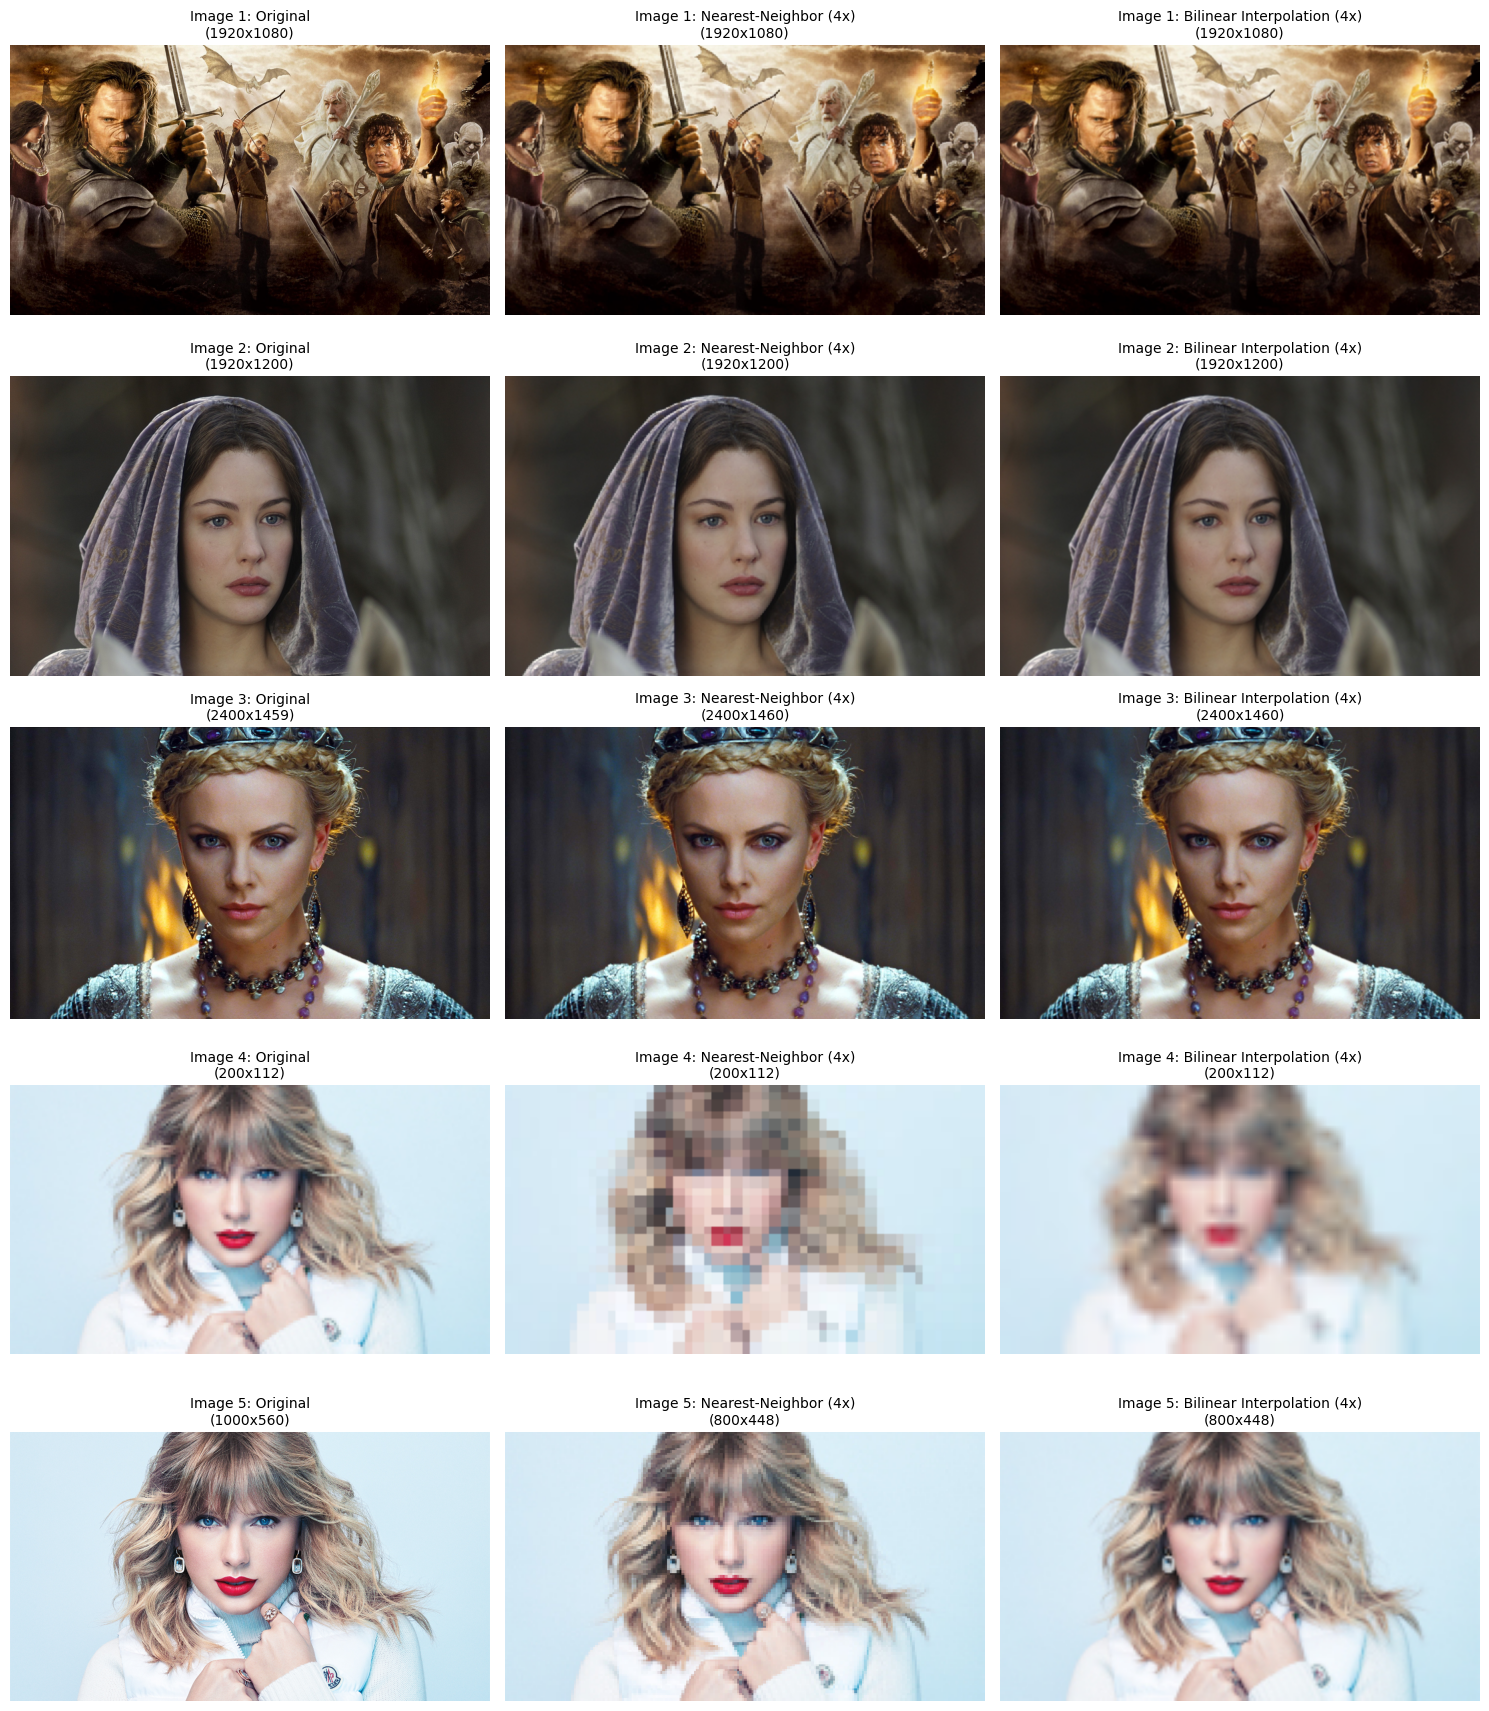

In [114]:
# Function to zoom an image using nearest neighbor or bilinear interpolation
def zoom_image(image, s, method='bilinear'):
    
    if not (0 < s <= 10):
        raise ValueError("Scale factor s must be in range (0, 10].")

    h_in, w_in = image.shape[:2]

    #calculate the dimensions of the output image
    h_out = int(round(h_in * s)) 
    w_out = int(round(w_in * s))

    #calculate the coordinates of the output image and map them back to the input image
    out_r, out_c = np.meshgrid(np.arange(h_out), np.arange(w_out), indexing='ij')
    in_r = out_r / s #map the output row coordinates back to the input image
    in_c = out_c / s #map the output column coordinates back to the input image

    #Nearest neighbor interpolation
    if method == 'nearest':
        r_nn = np.clip(np.round(in_r).astype(int), 0, h_in - 1)
        c_nn = np.clip(np.round(in_c).astype(int), 0, w_in - 1)
        return image[r_nn, c_nn]

    #Bilinear interpolation
    elif method == 'bilinear':
        r0 = np.clip(np.floor(in_r).astype(int), 0, h_in - 1)
        c0 = np.clip(np.floor(in_c).astype(int), 0, w_in - 1)
        r1 = np.clip(r0 + 1, 0, h_in - 1)
        c1 = np.clip(c0 + 1, 0, w_in - 1)

        dr = in_r - r0
        dc = in_c - c0

        if image.ndim == 3:
            dr = dr[:, :, np.newaxis]
            dc = dc[:, :, np.newaxis]

        i_00 = image[r0, c0]
        i_01 = image[r0, c1]
        i_10 = image[r1, c0]
        i_11 = image[r1, c1]

        zoomed = ( (1 - dr) * (1 - dc) * i_00 +
                   (1 - dr) * dc        * i_01 +
                   dr        * (1 - dc) * i_10 +
                   dr        * dc        * i_11 )

        return np.clip(zoomed, 0, 255).astype(image.dtype)
    else:
        raise ValueError("Invalid method. Choose 'nearest' or 'bilinear'.")

# defining a function to compute the normalized sum of squared differences (SSD) between two images
def compute_normalized_ssd(img1, img2):

    i1 = img1.astype(np.float64)
    i2 = img2.astype(np.float64)

    min_h = min(i1.shape[0], i2.shape[0])
    min_w = min(i1.shape[1], i2.shape[1])
    i1, i2 = i1[:min_h, :min_w], i2[:min_h, :min_w]

    ssd = np.sum((i1 - i2) ** 2)
    norm_factor = np.sqrt(np.sum(i1 ** 2) * np.sum(i2 ** 2))
    
    return ssd / norm_factor

#Loading the original and downsampled images
org_1 = cv2.imread("images/im01.png")
org_1_small = cv2.imread("images/im01small.png")
org_2 = cv2.imread("images/im02.png")
org_2_small = cv2.imread("images/im02small.png")
org_3 = cv2.imread("images/im03.png")
org_3_small = cv2.imread("images/im03small.png")
org_4 = cv2.imread("images/im04.jpg")
org_4_small = cv2.imread("images/im04small.jpg")
org_5 = cv2.imread("images/im05.jpg")

# zooming images using nearest neighbor and bilinear interpolation methods
zoomed_1_nearest = zoom_image(org_1_small, 4, method='nearest')
zoomed_2_nearest = zoom_image(org_2_small, 4, method='nearest')
zoomed_3_nearest = zoom_image(org_3_small, 4, method='nearest')
zoomed_4_nearest = zoom_image(org_4_small, 4, method='nearest')
zoomed_5_nearest = zoom_image(org_4, 4, method='nearest')

#zooming images using bilinear interpolation method
zoomed_1_bilinear = zoom_image(org_1_small, 4, method='bilinear')
zoomed_2_bilinear = zoom_image(org_2_small, 4, method='bilinear')
zoomed_3_bilinear = zoom_image(org_3_small, 4, method='bilinear')   
zoomed_4_bilinear = zoom_image(org_4_small, 4, method='bilinear')
zoomed_5_bilinear = zoom_image(org_4, 4, method='bilinear')

#print the normalized SSD values for both nearest neighbor and bilinear interpolation methods
print("\nNormalized SSD for Nearest Neighbor:")
print(f"Image 1: {compute_normalized_ssd(zoomed_1_nearest, org_1)}")
print(f"Image 2: {compute_normalized_ssd(zoomed_2_nearest, org_2)}")
print(f"Image 3: {compute_normalized_ssd(zoomed_3_nearest, org_3)}")
print(f"Image 4: {compute_normalized_ssd(zoomed_4_nearest, org_4)}")
print(f"Image 5: {compute_normalized_ssd(zoomed_5_nearest, org_5)}")

#print the normalized SSD values for bilinear interpolation method
print("\nNormalized SSD for Bilinear Interpolation:")
print(f"Image 1: {compute_normalized_ssd(zoomed_1_bilinear, org_1)}")
print(f"Image 2: {compute_normalized_ssd(zoomed_2_bilinear, org_2)}")
print(f"Image 3: {compute_normalized_ssd(zoomed_3_bilinear, org_3)}")   
print(f"Image 4: {compute_normalized_ssd(zoomed_4_bilinear, org_4)}")
print(f"Image 5: {compute_normalized_ssd(zoomed_5_bilinear, org_5)}")   

image_comparisons = [
    (org_1, zoomed_1_nearest, zoomed_1_bilinear, "Image 1"),
    (org_2, zoomed_2_nearest, zoomed_2_bilinear, "Image 2"),
    (org_3, zoomed_3_nearest, zoomed_3_bilinear, "Image 3"),
    (org_4, zoomed_4_nearest, zoomed_4_bilinear, "Image 4"),
    (org_5, zoomed_5_nearest, zoomed_5_bilinear, "Image 5")
]

# Set up a grid with 3 columns per image set (Original | Nearest Neighbor | Bilinear)
fig, axes = plt.subplots(len(image_comparisons), 3, figsize=(15, 3.5 * len(image_comparisons)))

for idx, (orig, nn, bl, name) in enumerate(image_comparisons):

    orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    nn_rgb = cv2.cvtColor(nn, cv2.COLOR_BGR2RGB)
    bl_rgb = cv2.cvtColor(bl, cv2.COLOR_BGR2RGB)

    # 1. Ground Truth Original
    axes[idx, 0].imshow(orig_rgb)
    axes[idx, 0].set_title(f"{name}: Original\n({orig.shape[1]}x{orig.shape[0]})", fontsize=10)
    axes[idx, 0].axis('off')

    # 2. Nearest-Neighbor Interpolation (s = 4)
    axes[idx, 1].imshow(nn_rgb)
    axes[idx, 1].set_title(f"{name}: Nearest-Neighbor (4x)\n({nn.shape[1]}x{nn.shape[0]})", fontsize=10)
    axes[idx, 1].axis('off')

    # 3. Bilinear Interpolation (s = 4)
    axes[idx, 2].imshow(bl_rgb)
    axes[idx, 2].set_title(f"{name}: Bilinear Interpolation (4x)\n({bl.shape[1]}x{bl.shape[0]})", fontsize=10)
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()

- Nearest-Neighbor Interpolation: This method simply assigns the value of the closest input pixel to the output grid. Visually, this creates a "blocky" or pixelated appearance, particularly noticeable on curved or diagonal edges (a phenomenon known as the staircase effect or aliasing). It is excellent for preserving sharp, distinct boundaries (like in pixel art or barcodes) but poor for natural photos.
- Bilinear Interpolation: By taking a weighted average of the 4 surrounding pixels, bilinear interpolation smooths the transitions between pixel values. The visual result is much smoother with significantly reduced blockiness, though it can make the zoomed image appear slightly blurry, as the averaging acts as a low-pass filter that suppresses high-frequency edge details.
- The Sum of Squared Differences (SSD) provides a mathematical metric to evaluate how close the reconstructed (zoomed) image is to the ground truth (the large original). Normalizing it ensures that the metric isn't skewed by the overall brightness or size of the image.
- We can observe from the numerical metrices that generally bilinear interpolation performs better when compared to nearest neighbour interpolation, the bilinear interpolation gives lesser error with respect to the original image

### 9 Background blurring
#### Extract the foreground of a given image and apply gaussian blurring to the cropped out background 

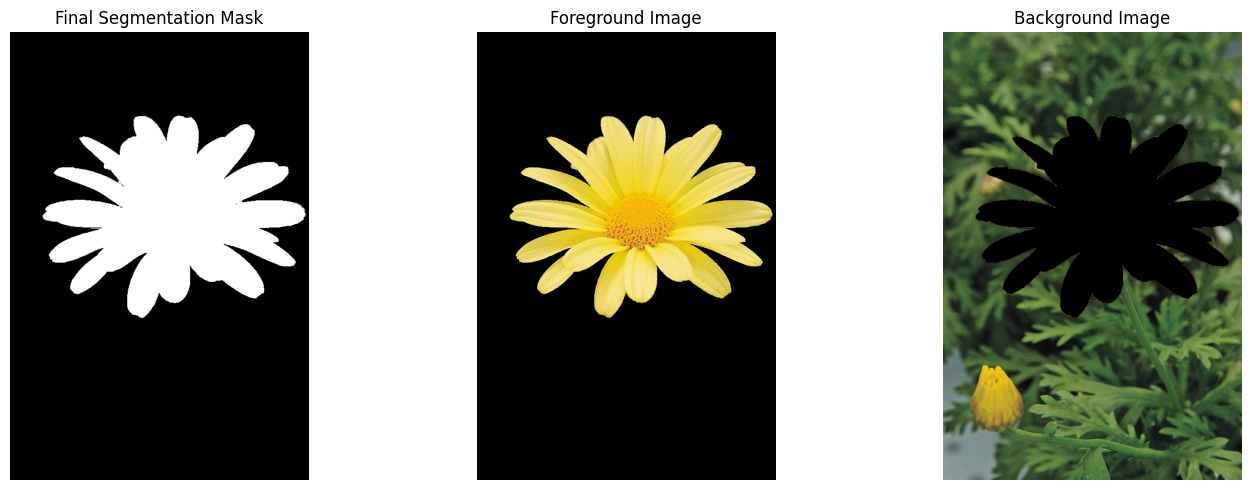

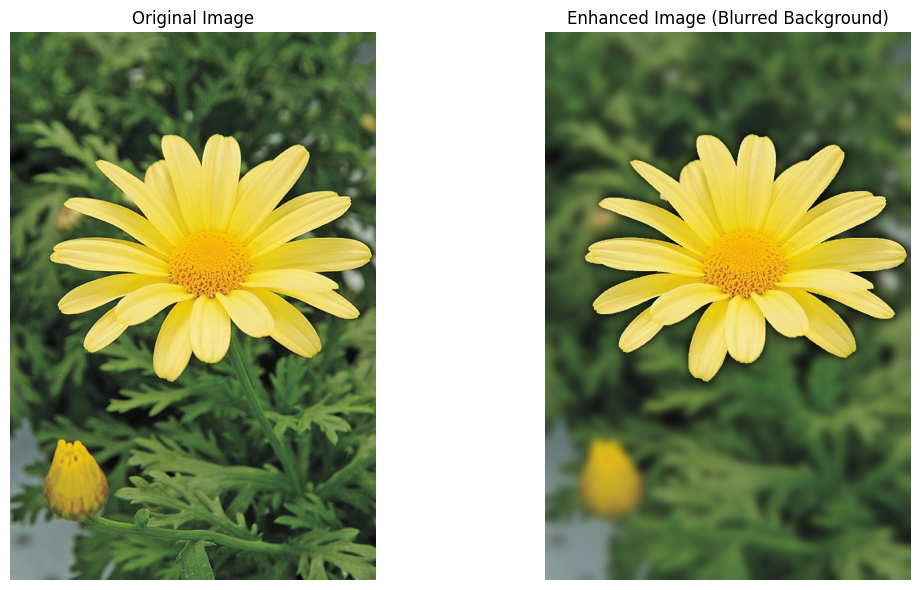

In [115]:
im9 = cv2.imread('images/q9.jpeg')
im9_rgb = cv2.cvtColor(im9, cv2.COLOR_BGR2RGB) #convert the image from BGR to RGB color space for display and processing
h, w = im9_rgb.shape[:2]

mask = np.zeros((h, w), np.uint8)
bgd_model = np.zeros((1, 65), np.float64) #initialize the background model for the GrabCut algorithm
fgd_model = np.zeros((1, 65), np.float64) #initialize the foreground model for the GrabCut algorithm

rect = (int(w * 0.11), int(h * 0.11), int(w * 0.95), int(h * 0.55)) #define the rectangle that roughly contains the foreground object
cv2.grabCut(im9_rgb, mask, rect, bgd_model, fgd_model, iterCount=5, mode=cv2.GC_INIT_WITH_RECT)

binary_mask = np.where((mask == 1) | (mask == 3), 1, 0).astype('uint8') #create the binary mask
    
foreground = cv2.bitwise_and(im9_rgb, im9_rgb, mask=binary_mask) # calculate the foreground of the image by applying the binary mask to the original RGB image, effectively isolating the areas of interest based on the GrabCut segmentation.
background = cv2.bitwise_and(im9_rgb, im9_rgb, mask=1 - binary_mask) #calculate the background of the image by applying the inverse of the binary mask to the original RGB image, effectively isolating the areas that were not part of the foreground.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
outputs_a = [
    (binary_mask * 255, "Final Segmentation Mask", "gray"),
    (foreground, "Foreground Image", None),
    (background, "Background Image", None)
]

for ax, (img, title, cmap) in zip(axes, outputs_a):
    ax.imshow(img, cmap=cmap) if cmap else ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

blurred_back = cv2.GaussianBlur(background, (41, 41), 0) # apply a Gaussian blur to the background image to create a blurred effect, using a kernel size of (41, 41) and a standard deviation of 0. This will help in enhancing the foreground by making it stand out against the blurred background. 

enhanced_img = np.where(binary_mask[:, :, np.newaxis] == 1, im9_rgb, blurred_back) #combine the original image and the blurred background using the binary mask. The foreground pixels (where the mask is 1) are taken from the original image, while the background pixels (where the mask is 0) are taken from the blurred background. This results in an enhanced image where the foreground stands out against a blurred background.

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
outputs_b = [
    (im9_rgb, "Original Image"),
    (enhanced_img, "Enhanced Image (Blurred Background)")
]

for ax, (img, title) in zip(axes, outputs_b):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

- Bounding box initialization builds Gaussian Mixture Models (GMMs) for foreground/background colors, allowing iterative graph-cut optimization to segment the flower automatically.
- Combining definite and probable foreground states (mask == 1 and mask == 3) collapses GrabCut's 4-state output into a clean binary mask.
- Applying a large Gaussian blur ($41 \times 41$) strictly to the background before recombining it with the sharp flower artificially recreates a shallow depth-of-field (bokeh effect).
- Masking out the flower leaves a region of pure black ($0$) pixels in the background image. During spatial convolution, the large Gaussian kernel averages nearby valid background pixels with these zero values, bleeding black inward and creating a dark halo around the flower's outline.

### 10 Bilateral filtering
#### We apply bilateral filtering to blurr an given image without destroying or damaging the sharp edges of the image.

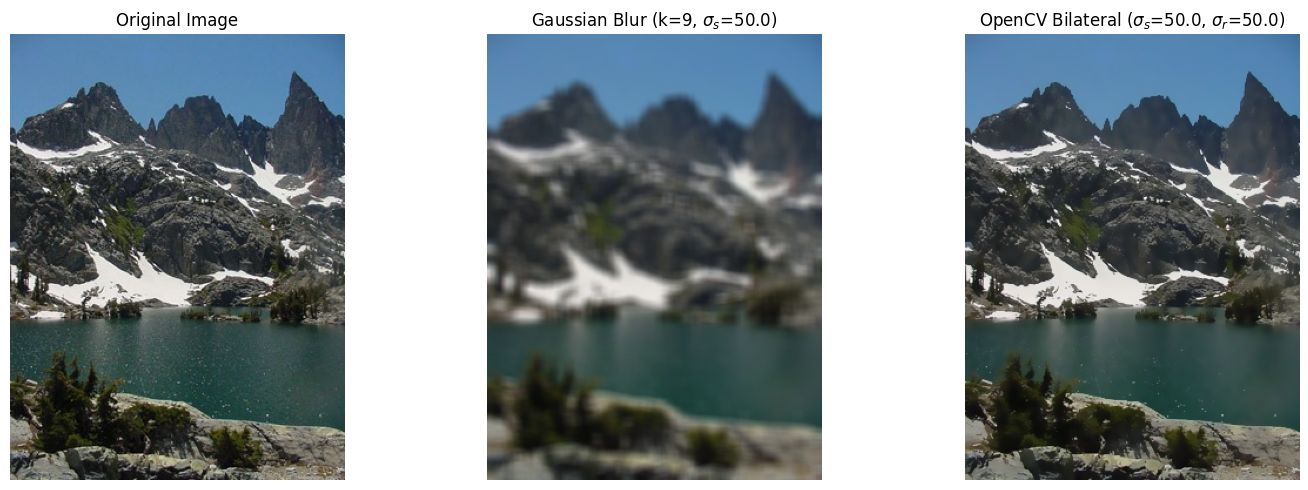

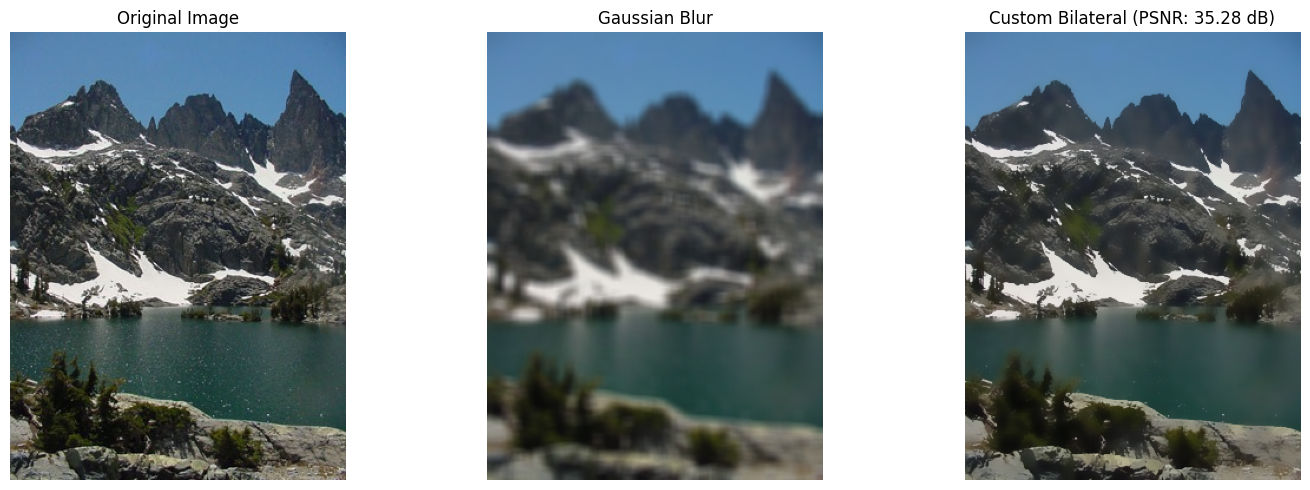

Mean Squared Error (MSE): 19.2601
Peak Signal-to-Noise Ratio (PSNR): 35.28 dB


In [116]:
im10 = cv2.imread('images/q10.jpeg')
im10_rgb = cv2.cvtColor(im10, cv2.COLOR_BGR2RGB)

d = 9             # Window size (diameter)
sigma_s = 50.0    # Spatial standard deviation (coordinate distance)
sigma_r = 50.0    # Range standard deviation (color intensity difference)

cv_bilateral = cv2.bilateralFilter(im10_rgb, d, sigma_r, sigma_s) #apply OpenCV's built-in bilateral filter to the image
gaussian_blur = cv2.GaussianBlur(im10_rgb, (d, d), sigmaX=sigma_s) #apply Gaussian blur to the image for comparison with the bilateral filter

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
outputs_a = [
    (im10_rgb, "Original Image"),
    (gaussian_blur, rf"Gaussian Blur (k={d}, $\sigma_s$={sigma_s})"),
    (cv_bilateral, rf"OpenCV Bilateral ($\sigma_s$={sigma_s}, $\sigma_r$={sigma_r})")
]

for ax, (img, title) in zip(axes, outputs_a):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# defining a custom bilateral filter function that takes an image, window size, spatial standard deviation, and range standard deviation as input and returns the filtered image.
def custom_bilateral_filter(image, d, sigma_r, sigma_s):
    h, w, c = image.shape
    result = np.zeros_like(image, dtype=np.float32)
    radius = d // 2
    
    y, x = np.mgrid[-radius:radius+1, -radius:radius+1]
    spatial_weights = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))
    
    padded_img = np.pad(image, ((radius, radius), (radius, radius), (0, 0)), mode='reflect').astype(np.float32)
    
    for i in range(h):
        for j in range(w):
            window = padded_img[i:i+d, j:j+d, :]
            center_pixel = padded_img[i+radius, j+radius, :]
            
            color_diffs = np.sum((window - center_pixel)**2, axis=2)
            range_weights = np.exp(-color_diffs / (2 * sigma_r**2))
                
            total_weights = spatial_weights * range_weights
            weight_sum = np.sum(total_weights)
            
            for k in range(c):
                result[i, j, k] = np.sum(total_weights * window[:, :, k]) / weight_sum
                
    return np.clip(result, 0, 255).astype(np.uint8)

custom_bilateral = custom_bilateral_filter(im10_rgb, d, sigma_r, sigma_s)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
outputs_b = [
    (im10_rgb, "Original Image"),
    (gaussian_blur, "Gaussian Blur"),
    (custom_bilateral, rf"Custom Bilateral (PSNR: {psnr:.2f} dB)")
]

for ax, (img, title) in zip(axes, outputs_b):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

mse = np.mean((cv_bilateral.astype(np.float64) - custom_bilateral.astype(np.float64)) ** 2)

max_pixel = 255.0
psnr = 10 * np.log10((max_pixel ** 2) / mse) if mse > 0 else float('inf')
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {psnr:.2f} dB")

- Unlike Gaussian blur, which averages pixels strictly based on spatial proximity ($\sigma_s$) and consequently blurs edges, the bilateral filter introduces a range weight ($\sigma_r$) to suppress averaging across sharp color boundaries.
- In the custom implementation, range_weights drops toward zero when the Euclidean color difference between a neighbor and the center pixel is large. This prevents cross-boundary bleeding, keeping the structures of Lake Minaret sharply defined while smoothing the sky and water
- To optimize the custom algorithm, constant spatial weights are pre-computed globally using np.mgrid, while local RGB color differences are calculated natively via vectorized NumPy array operations (np.sum) within the moving $d \times d$ window.
- Mean Squared Error (MSE) evaluates the exact pixel variance between the custom code and OpenCV's baseline. Translating this to Peak Signal-to-Noise Ratio (PSNR) provides a standard decibel metric; a high PSNR (typically $>35$ dB) mathematically proves the custom implementation accurately replicates the optimized OpenCV algorithm.